# RCPSP Heuristic Comparison: Results Analysis

This notebook analyzes and compares four A* heuristic configurations for solving the
Resource-Constrained Project Scheduling Problem (RCPSP) using Petri Net modeling
with Timed Transitions (TT):

| Label | Heuristic | DP | Solved |
|-------|-----------|-----|--------|
| CP_DP | Critical Path | Yes | 369/480 |
| CP_NoDP | Critical Path | No | 368/480 |
| LBCS | Lower Bound Critical Sequence | Yes | 381/480 |
| LBCC | Lower Bound Critical Chain | Yes | 361/480 |

**Dataset**: KSD j30 benchmark, groups 1–48, exams 1–10 (480 instances each).  
**Timeout**: 300 seconds. Unsolved instances marked with `finished=False`.  
**RS (Resource Strength)**: Derived from group number: `(group-1) % 4` maps to {0.2, 0.5, 0.7, 1.0}.

## Sections
1. **DP vs NoDP Comparison** (CPM heuristic only)
2. **Heuristic Comparison** (CP_DP vs LBCS vs LBCC)
3. **Comparison with Previous Project**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings
warnings.filterwarnings('ignore')

# --- Style Setup ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

# --- Color Palette ---
COLORS = {
    'CP': '#2196F3',       # blue
    'CP_DP': '#2196F3',    # blue
    'CP_NoDP': '#64B5F6',  # lighter blue
    'LBCS': '#4CAF50',     # green
    'LBCC': '#FF9800',     # orange
    'previous': '#9E9E9E', # gray
}

# --- Output directory for figures ---
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


In [2]:
def add_bar_labels(ax, bars, fmt='{:.0f}', fontsize=10, offset=0.01):
    """Add value labels on top of vertical bars."""
    ymax = ax.get_ylim()[1]
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + ymax * offset,
                fmt.format(height), ha='center', va='bottom',
                fontsize=fontsize, fontweight='bold')

def add_bar_labels_h(ax, bars, fmt='{:.0f}', fontsize=10):
    """Add value labels on horizontal bars."""
    for bar in bars:
        width = bar.get_width()
        ax.text(width + ax.get_xlim()[1] * 0.01,
                bar.get_y() + bar.get_height() / 2.,
                fmt.format(width), ha='left', va='center',
                fontsize=fontsize, fontweight='bold')

def savefig(fig, name):
    """Save figure as PNG in figures/ directory."""
    path = os.path.join(FIG_DIR, f'{name}.png')
    fig.savefig(path, bbox_inches='tight', dpi=150)
    print(f'Saved: {path}')

def compute_rs(group):
    """Map group number to Resource Strength (RS) value."""
    mapping = {0: 0.2, 1: 0.5, 2: 0.7, 3: 1.0}
    return mapping[(group - 1) % 4]

print('Helper functions defined.')

Helper functions defined.


## Data Loading

Loading four CSV files (480 rows each):
- **CP_DP**: `data/real_data/2026-02-01_j30_g1-48_e1-10_tt_cp_dp.csv`
- **CP_NoDP**: `data/real_data/2026-02-01_j30_g1-48_e1-10_tt_cp_nodp.csv`
- **LBCS**: `data/real_data/2026-02-02_j30_g1-48_e1-10_tt_lbcs.csv`
- **LBCC**: `data/2026-02-09_j30_g1-48_e1-10_tt_lbcc.csv` *(different directory)*

Each row is one problem instance identified by `(group, exam)`.

In [3]:
DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data') if os.path.exists(os.path.join(os.path.dirname(os.getcwd()), 'data')) else 'data'
if os.path.exists('data'):
    DATA_PATH = 'data'
print(f'Data path: {DATA_PATH}')

files = {
    'CP_DP':   os.path.join(DATA_PATH, 'real_data', '2026-02-01_j30_g1-48_e1-10_tt_cp_dp.csv'),
    'CP_NoDP': os.path.join(DATA_PATH, 'real_data', '2026-02-01_j30_g1-48_e1-10_tt_cp_nodp.csv'),
    'LBCS':    os.path.join(DATA_PATH, 'real_data', '2026-02-02_j30_g1-48_e1-10_tt_lbcs.csv'),
    'LBCC':    os.path.join(DATA_PATH, '2026-02-09_j30_g1-48_e1-10_tt_lbcc.csv'),
}

dfs = {}
for name, path in files.items():
    df = pd.read_csv(path)
    if df['finished'].dtype == object:
        df['finished'] = df['finished'].str.strip().str.upper() == 'TRUE'
    else:
        df['finished'] = df['finished'].astype(bool)
    df['RS'] = df['group'].apply(compute_rs)
    df['problem_id'] = df['group'].astype(str) + ':' + df['exam'].astype(str)
    df['heuristic_label'] = name
    dfs[name] = df
    solved = df['finished'].sum()
    print(f'{name}: {len(df)} rows, {solved} solved, {len(df) - solved} timeout')

assert all(len(df) == 480 for df in dfs.values()), 'Expected 480 rows per file'

Data path: data
CP_DP: 480 rows, 369 solved, 111 timeout
CP_NoDP: 480 rows, 368 solved, 112 timeout
LBCS: 480 rows, 381 solved, 99 timeout
LBCC: 480 rows, 361 solved, 119 timeout


In [4]:
# Build merged wide-format DataFrame
cols_to_keep = ['group', 'exam', 'RS', 'problem_id', 'time', 'finished', 'makespan',
                'expand_number', 'generated_number']

merged = dfs['CP_DP'][cols_to_keep].copy()
merged.columns = ['group', 'exam', 'RS', 'problem_id'] + [f'{c}_cp' for c in cols_to_keep[4:]]

for name, suffix in [('CP_NoDP', '_nodp'), ('LBCS', '_lbcs'), ('LBCC', '_lbcc')]:
    right = dfs[name][['group', 'exam'] + list(cols_to_keep[4:])].copy()
    right.columns = ['group', 'exam'] + [f'{c}{suffix}' for c in cols_to_keep[4:]]
    merged = merged.merge(right, on=['group', 'exam'], how='outer')

print(f'Merged shape: {merged.shape}')
merged.head()

Merged shape: (480, 24)


,group,exam,RS,problem_id,time_cp,finished_cp,makespan_cp,expand_number_cp,generated_number_cp,time_nodp,...,time_lbcs,finished_lbcs,makespan_lbcs,expand_number_lbcs,generated_number_lbcs,time_lbcc,finished_lbcc,makespan_lbcc,expand_number_lbcc,generated_number_lbcc
0,1,1,0.2,1:1,0.519396,True,43,28427,184301,0.789194,...,0.298102,True,43,10165,65944,1.02078,True,43,28424,184291
1,1,2,0.2,1:2,3.685130,True,47,295365,1433819,4.958730,...,3.357900,True,47,185953,921702,5.14387,True,47,295365,1433819
2,1,3,0.2,1:3,3.725660,True,47,362628,1622885,5.410530,...,2.873530,True,47,174791,804392,5.62691,True,47,354799,1586033
3,1,4,0.2,1:4,228.128000,True,62,6432334,31082819,261.966000,...,7.820800,True,62,452610,2120979,269.65600,True,62,6238527,30009546
4,1,5,0.2,1:5,40.691900,True,39,2782624,13521140,47.603400,...,12.597700,True,39,664254,3344440,24.42250,True,39,1491217,7074797


---
# Section 1: DP vs NoDP Comparison (CPM Heuristic)

This section isolates the effect of Dynamic Programming (DP) duplicate detection by
comparing CP_DP (369 solved) vs CP_NoDP (368 solved), both using the Critical Path
heuristic but differing only in DP usage.

**Goal**: Show that DP makes the system faster per-node without changing search behavior.

### 1.1 Solve Rate Comparison

**Key takeaway**: DP and NoDP solve nearly identical numbers of instances (369 vs 368),
confirming that DP does not change search behavior — only speed.

Saved: figures/graph_1_1_solve_rate_dp_nodp.png


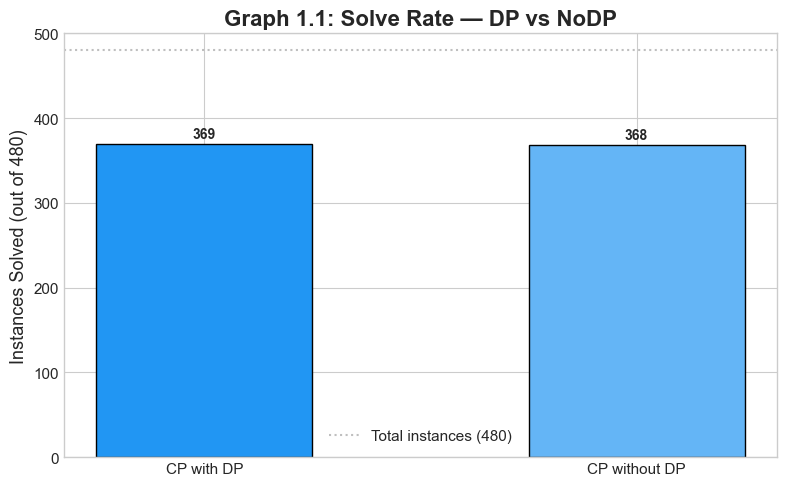

In [5]:
solved_dp = dfs['CP_DP']['finished'].sum()
solved_nodp = dfs['CP_NoDP']['finished'].sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['CP with DP', 'CP without DP'],
              [solved_dp, solved_nodp],
              color=[COLORS['CP_DP'], COLORS['CP_NoDP']],
              edgecolor='black', width=0.5)
add_bar_labels(ax, bars)
ax.set_ylabel('Instances Solved (out of 480)')
ax.set_title('Graph 1.1: Solve Rate \u2014 DP vs NoDP')
ax.set_ylim(0, 500)
ax.axhline(y=480, color='gray', linestyle=':', alpha=0.5, label='Total instances (480)')
ax.legend()
plt.tight_layout()
savefig(fig, 'graph_1_1_solve_rate_dp_nodp')
plt.show()

### 1.2 Runtime Speedup Distribution

For instances solved by **both** heuristics, we compute `speedup = time_nodp / time_dp`.
A speedup > 1 means DP was faster.

**Key takeaway**: Average speedup is ~1.32x, meaning DP is on average 32% faster per instance.

Instances solved by both: 368
Saved: figures/graph_1_2_speedup_histogram.png


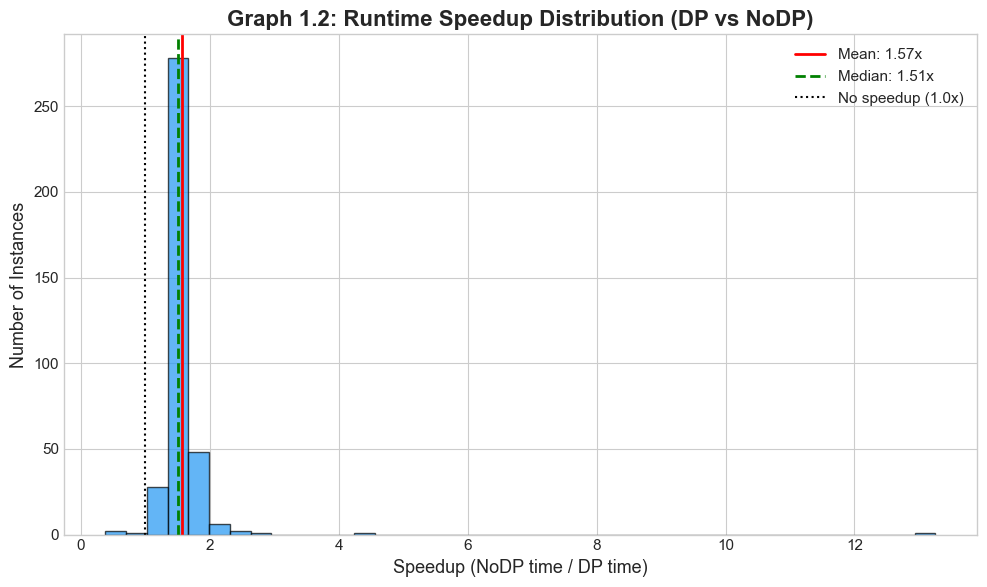

Average speedup: 1.57x
Median speedup: 1.51x
DP faster in 365/368 instances (99.2%)


In [6]:
both_solved_dp = merged[
    (merged['finished_cp'] == True) & (merged['finished_nodp'] == True)
].copy()
print(f'Instances solved by both: {len(both_solved_dp)}')

both_solved_dp['speedup'] = both_solved_dp['time_nodp'] / both_solved_dp['time_cp']

avg_speedup = both_solved_dp['speedup'].mean()
med_speedup = both_solved_dp['speedup'].median()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(both_solved_dp['speedup'], bins=40,
        color=COLORS['CP_DP'], edgecolor='black', alpha=0.7)
ax.axvline(x=avg_speedup, color='red', linestyle='-', linewidth=2,
           label=f'Mean: {avg_speedup:.2f}x')
ax.axvline(x=med_speedup, color='green', linestyle='--', linewidth=2,
           label=f'Median: {med_speedup:.2f}x')
ax.axvline(x=1.0, color='black', linestyle=':', linewidth=1.5,
           label='No speedup (1.0x)')
ax.set_xlabel('Speedup (NoDP time / DP time)')
ax.set_ylabel('Number of Instances')
ax.set_title('Graph 1.2: Runtime Speedup Distribution (DP vs NoDP)')
ax.legend(fontsize=11)
plt.tight_layout()
savefig(fig, 'graph_1_2_speedup_histogram')
plt.show()

print(f'Average speedup: {avg_speedup:.2f}x')
print(f'Median speedup: {med_speedup:.2f}x')
print(f'DP faster in {(both_solved_dp["speedup"] > 1).sum()}/{len(both_solved_dp)} instances '
      f'({(both_solved_dp["speedup"] > 1).mean()*100:.1f}%)')

### 1.3 Expanded Nodes in Mutually Unsolved Instances

For instances where **both** DP and NoDP timed out, we compare the average number of
expanded nodes. More nodes expanded in the same timeout = faster per-node throughput.

**Key takeaway**: DP expanded ~3.6M nodes on average vs ~2.9M for NoDP.
DP explored more nodes in 109/111 (98%) of mutual timeouts, proving faster per-node processing.

Instances where both timed out: 111
Saved: figures/graph_1_3_expanded_nodes_unsolved.png


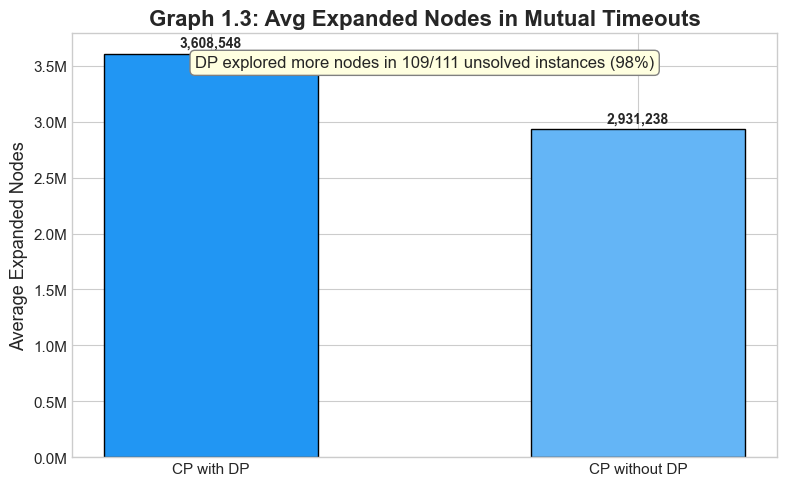

DP avg expanded: 3,608,548
NoDP avg expanded: 2,931,238
Ratio: 1.23x


In [7]:
both_unsolved = merged[
    (merged['finished_cp'] == False) & (merged['finished_nodp'] == False)
].copy()
print(f'Instances where both timed out: {len(both_unsolved)}')

avg_expand_dp = both_unsolved['expand_number_cp'].mean()
avg_expand_nodp = both_unsolved['expand_number_nodp'].mean()
dp_explored_more = (both_unsolved['expand_number_cp'] > both_unsolved['expand_number_nodp']).sum()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['CP with DP', 'CP without DP'],
              [avg_expand_dp, avg_expand_nodp],
              color=[COLORS['CP_DP'], COLORS['CP_NoDP']],
              edgecolor='black', width=0.5)
add_bar_labels(ax, bars, fmt='{:,.0f}')
ax.set_ylabel('Average Expanded Nodes')
ax.set_title('Graph 1.3: Avg Expanded Nodes in Mutual Timeouts')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Annotation
ax.annotate(
    f'DP explored more nodes in {dp_explored_more}/{len(both_unsolved)} '
    f'unsolved instances ({dp_explored_more/len(both_unsolved)*100:.0f}%)',
    xy=(0.5, 0.92), xycoords='axes fraction', ha='center', fontsize=12,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
savefig(fig, 'graph_1_3_expanded_nodes_unsolved')
plt.show()

print(f'DP avg expanded: {avg_expand_dp:,.0f}')
print(f'NoDP avg expanded: {avg_expand_nodp:,.0f}')
print(f'Ratio: {avg_expand_dp/avg_expand_nodp:.2f}x')

### 1.4 Runtime Scatter Plot (Both Solved)

Scatter plot of runtime for instances solved by both DP and NoDP.
Points below the diagonal (y=x) mean DP was faster.

**Key takeaway**: The majority of points fall below the diagonal, confirming DP's
consistent speed advantage. Color encodes Resource Strength (RS).

Saved: figures/graph_1_4_scatter_dp_nodp.png


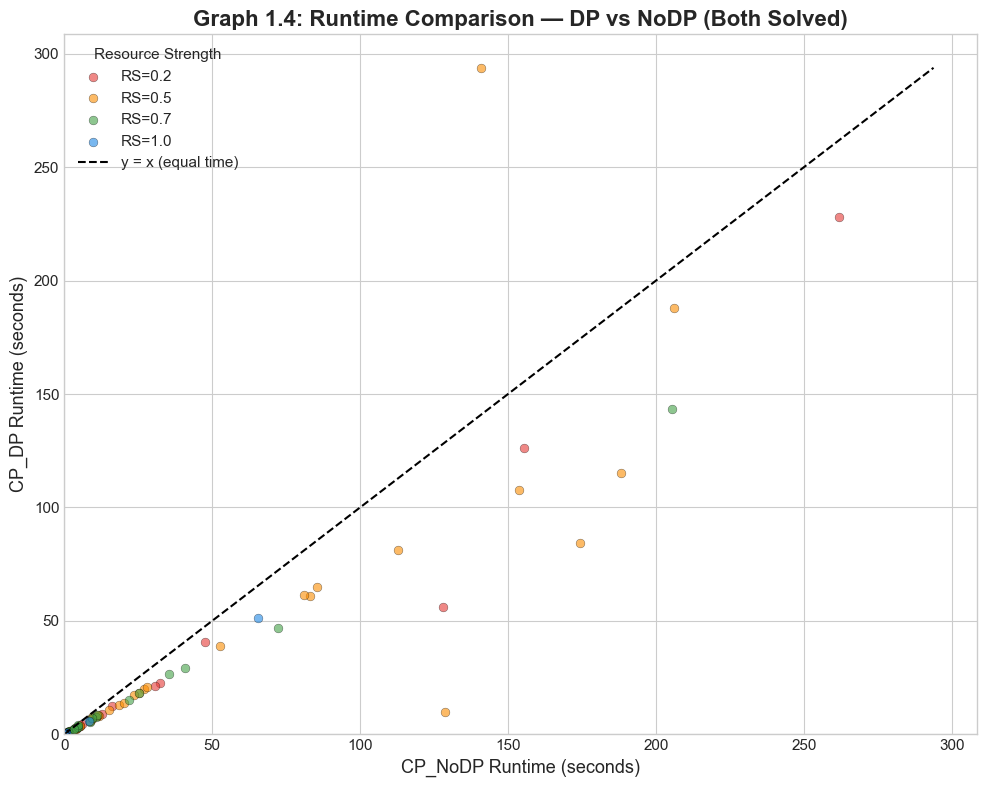

In [8]:
rs_colors = {0.2: '#E53935', 0.5: '#FB8C00', 0.7: '#43A047', 1.0: '#1E88E5'}

fig, ax = plt.subplots(figsize=(10, 8))
for rs_val, color in rs_colors.items():
    subset = both_solved_dp[both_solved_dp['RS'] == rs_val]
    ax.scatter(subset['time_nodp'], subset['time_cp'], c=color,
               label=f'RS={rs_val}', alpha=0.6, edgecolors='black',
               linewidths=0.3, s=40)

max_time = max(both_solved_dp['time_nodp'].max(), both_solved_dp['time_cp'].max())
ax.plot([0, max_time], [0, max_time], 'k--', linewidth=1.5, label='y = x (equal time)')

ax.set_xlabel('CP_NoDP Runtime (seconds)')
ax.set_ylabel('CP_DP Runtime (seconds)')
ax.set_title('Graph 1.4: Runtime Comparison \u2014 DP vs NoDP (Both Solved)')
ax.legend(title='Resource Strength')
ax.set_xlim(0, max_time * 1.05)
ax.set_ylim(0, max_time * 1.05)
plt.tight_layout()
savefig(fig, 'graph_1_4_scatter_dp_nodp')
plt.show()

---
# Section 2: Heuristic Comparison (CP_DP vs LBCS vs LBCC)

This section compares the three heuristics that all use DP: CP_DP (Critical Path),
LBCS (Lower Bound Critical Sequence), and LBCC (Lower Bound Critical Chain).

**Goal**: Compare which heuristic solves the most and analyze the accuracy vs. speed trade-off.

### 2.1 Overall Solve Rates

**Key takeaway**: LBCS leads with 381/480, followed by CP (369) and LBCC (361).
All three exceed the previous project baseline of 354 (dashed line).

Saved: figures/graph_2_1_solve_rates.png


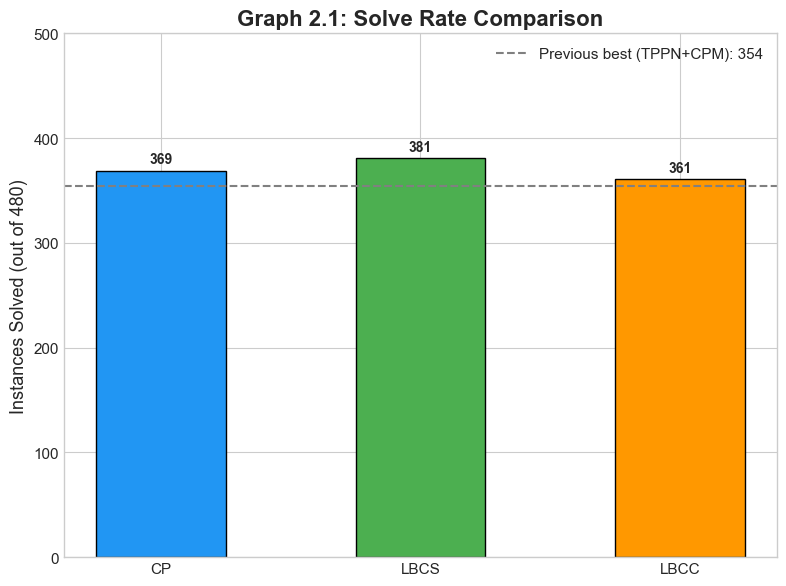

In [9]:
heuristics = ['CP_DP', 'LBCS', 'LBCC']
h_labels = ['CP', 'LBCS', 'LBCC']
solved_counts = [dfs[h]['finished'].sum() for h in heuristics]
h_colors = [COLORS[h] for h in heuristics]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(h_labels, solved_counts, color=h_colors, edgecolor='black', width=0.5)
add_bar_labels(ax, bars)
ax.axhline(y=354, color='gray', linestyle='--', linewidth=1.5,
           label='Previous best (TPPN+CPM): 354')
ax.legend(fontsize=11)
ax.set_ylabel('Instances Solved (out of 480)')
ax.set_title('Graph 2.1: Solve Rate Comparison')
ax.set_ylim(0, 500)
plt.tight_layout()
savefig(fig, 'graph_2_1_solve_rates')
plt.show()

### 2.2 Solve Rate by Resource Strength (RS)

Breakdown of solve rates across 4 RS levels (0.2, 0.5, 0.7, 1.0).
Each RS group has 120 instances (12 groups \u00d7 10 exams).

**Key takeaway**: All heuristics perform best at high RS and worst at low RS.
LBCS shows a particular advantage at intermediate RS values.

Saved: figures/graph_2_2_solve_rate_by_rs.png


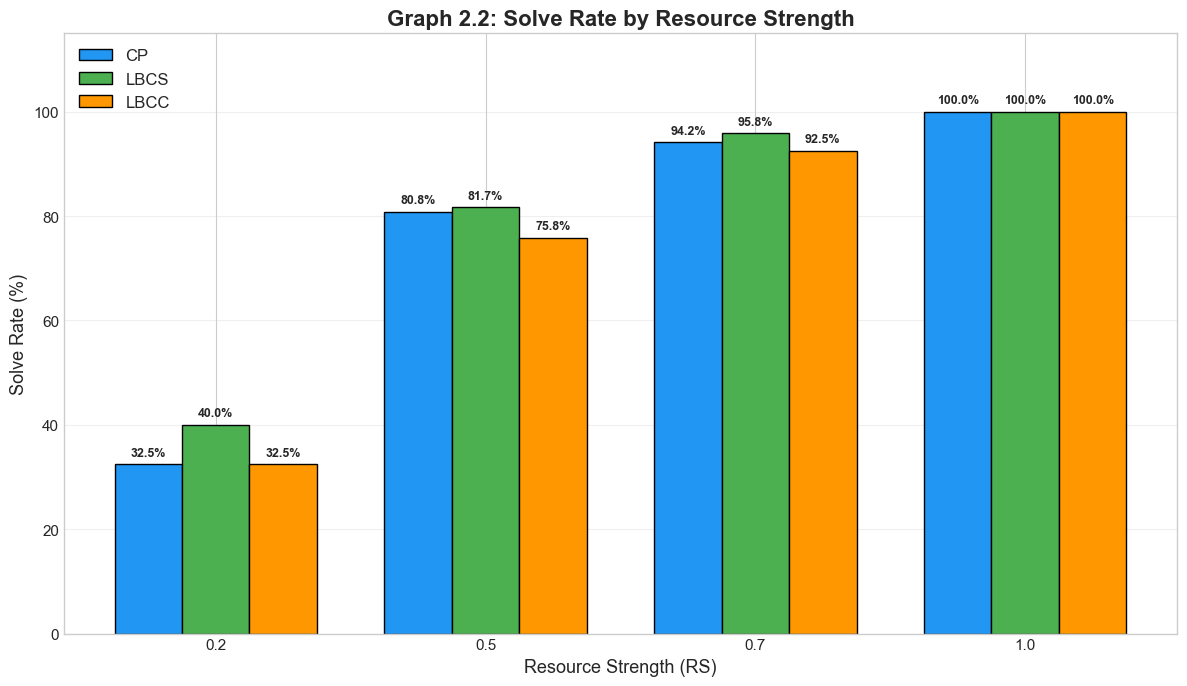

RS    CP          LBCS        LBCC        
0.2   32.5        40.0        32.5        
0.5   80.8        81.7        75.8        
0.7   94.2        95.8        92.5        
1.0   100.0       100.0       100.0       


In [10]:
rs_values = [0.2, 0.5, 0.7, 1.0]

solve_by_rs = {}
for h in heuristics:
    solve_by_rs[h] = []
    for rs in rs_values:
        subset = dfs[h][dfs[h]['RS'] == rs]
        pct = subset['finished'].sum() / len(subset) * 100
        solve_by_rs[h].append(pct)

x = np.arange(len(rs_values))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))
for i, (h, label) in enumerate(zip(heuristics, h_labels)):
    bars = ax.bar(x + i * width, solve_by_rs[h], width,
                  label=label, color=COLORS[h], edgecolor='black')
    add_bar_labels(ax, bars, fmt='{:.1f}%', fontsize=9)

ax.set_xlabel('Resource Strength (RS)')
ax.set_ylabel('Solve Rate (%)')
ax.set_title('Graph 2.2: Solve Rate by Resource Strength')
ax.set_xticks(x + width)
ax.set_xticklabels([str(rs) for rs in rs_values])
ax.set_ylim(0, 115)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
savefig(fig, 'graph_2_2_solve_rate_by_rs')
plt.show()

# Print table
print(f'{"RS":<6}', end='')
for label in h_labels:
    print(f'{label:<12}', end='')
print()
for j, rs in enumerate(rs_values):
    print(f'{rs:<6.1f}', end='')
    for h in heuristics:
        print(f'{solve_by_rs[h][j]:<12.1f}', end='')
    print()

### 2.3 Average Expanded Nodes by RS (All Three Solved)

For instances solved by all three heuristics, we compare average expanded nodes per RS group.

**Key takeaway**: LBCC has dramatically fewer nodes at RS=1.0 (e.g., ~49 vs ~14,000 for CP)
but shows similar or worse performance at low RS.

Instances solved by all three: 355
Saved: figures/graph_2_3_expanded_by_rs.png


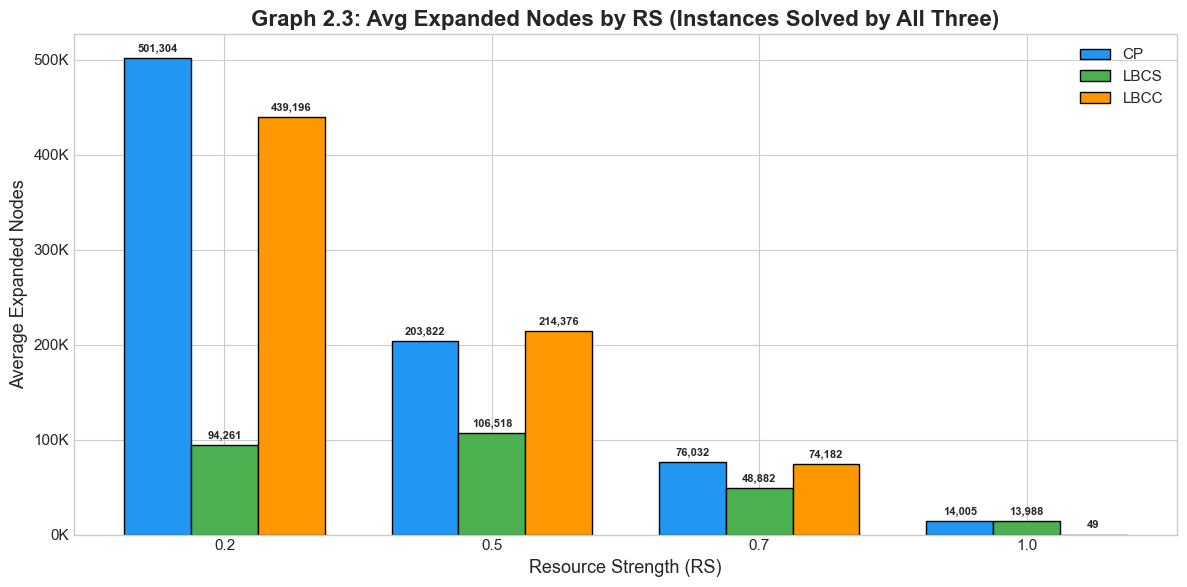

RS    CP             LBCS           LBCC           
0.2   501,304        94,261         439,196        
0.5   203,822        106,518        214,376        
0.7   76,032         48,882         74,182         
1.0   14,005         13,988         49             


In [11]:
all_three_solved = merged[
    (merged['finished_cp'] == True) &
    (merged['finished_lbcs'] == True) &
    (merged['finished_lbcc'] == True)
].copy()
print(f'Instances solved by all three: {len(all_three_solved)}')

expand_cols = {
    'CP_DP': 'expand_number_cp',
    'LBCS': 'expand_number_lbcs',
    'LBCC': 'expand_number_lbcc'
}

x = np.arange(len(rs_values))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, (h, label) in enumerate(zip(heuristics, h_labels)):
    col = expand_cols[h]
    means = [all_three_solved[all_three_solved['RS'] == rs][col].mean()
             for rs in rs_values]
    bars = ax.bar(x + i * width, means, width,
                  label=label, color=COLORS[h], edgecolor='black')
    add_bar_labels(ax, bars, fmt='{:,.0f}', fontsize=8)

ax.set_xlabel('Resource Strength (RS)')
ax.set_ylabel('Average Expanded Nodes')
ax.set_title('Graph 2.3: Avg Expanded Nodes by RS (Instances Solved by All Three)')
ax.set_xticks(x + width)
ax.set_xticklabels([str(rs) for rs in rs_values])
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda val, _: f'{val/1e3:.0f}K' if val < 1e6 else f'{val/1e6:.1f}M'))
ax.legend()
plt.tight_layout()
savefig(fig, 'graph_2_3_expanded_by_rs')
plt.show()

# Print table
print(f'{"RS":<6}', end='')
for label in h_labels:
    print(f'{label:<15}', end='')
print()
for rs in rs_values:
    print(f'{rs:<6.1f}', end='')
    for h in heuristics:
        col = expand_cols[h]
        val = all_three_solved[all_three_solved['RS'] == rs][col].mean()
        print(f'{val:<15,.0f}', end='')
    print()

### 2.4 Average Expanded Nodes (Overall)

Average expanded nodes for each heuristic's own solved instances.

**Key takeaway**: LBCC is the most node-efficient (~165K), followed by LBCS (~227K), then CP (~251K).

Saved: figures/graph_2_4_avg_expanded_overall.png


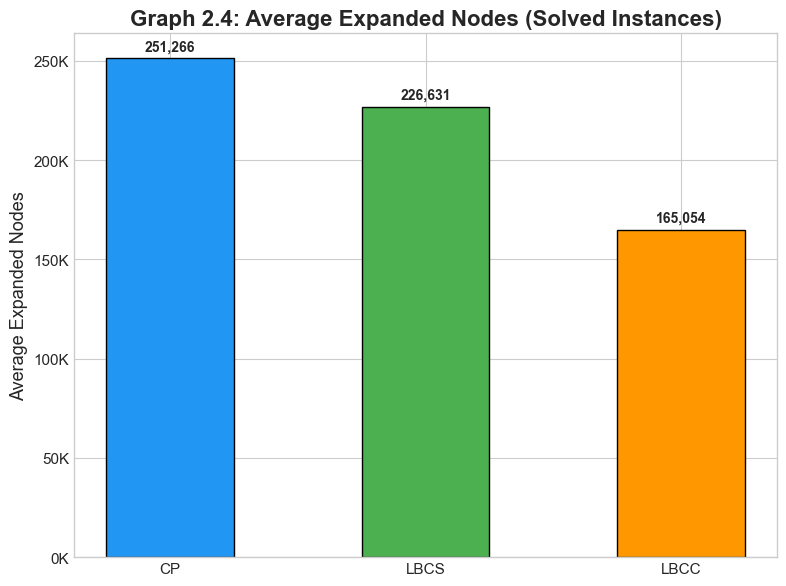

CP: 251,266
LBCS: 226,631
LBCC: 165,054


In [12]:
avg_expanded = {}
for h, label in zip(heuristics, h_labels):
    solved = dfs[h][dfs[h]['finished'] == True]
    avg_expanded[label] = solved['expand_number'].mean()

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(avg_expanded.keys(), avg_expanded.values(),
              color=[COLORS['CP_DP'], COLORS['LBCS'], COLORS['LBCC']],
              edgecolor='black', width=0.5)
add_bar_labels(ax, bars, fmt='{:,.0f}')
ax.set_ylabel('Average Expanded Nodes')
ax.set_title('Graph 2.4: Average Expanded Nodes (Solved Instances)')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda val, _: f'{val/1e3:.0f}K'))
plt.tight_layout()
savefig(fig, 'graph_2_4_avg_expanded_overall')
plt.show()

for name, val in avg_expanded.items():
    print(f'{name}: {val:,.0f}')

### 2.5 Solving Time Distribution

Breakdown of instances by time buckets: 0–10s, 10–60s, 1–2min, 2–5min, and Timeout.

**Key takeaway**: LBCS solves more instances quickly and has fewer timeouts overall.

Saved: figures/graph_2_5_time_distribution.png


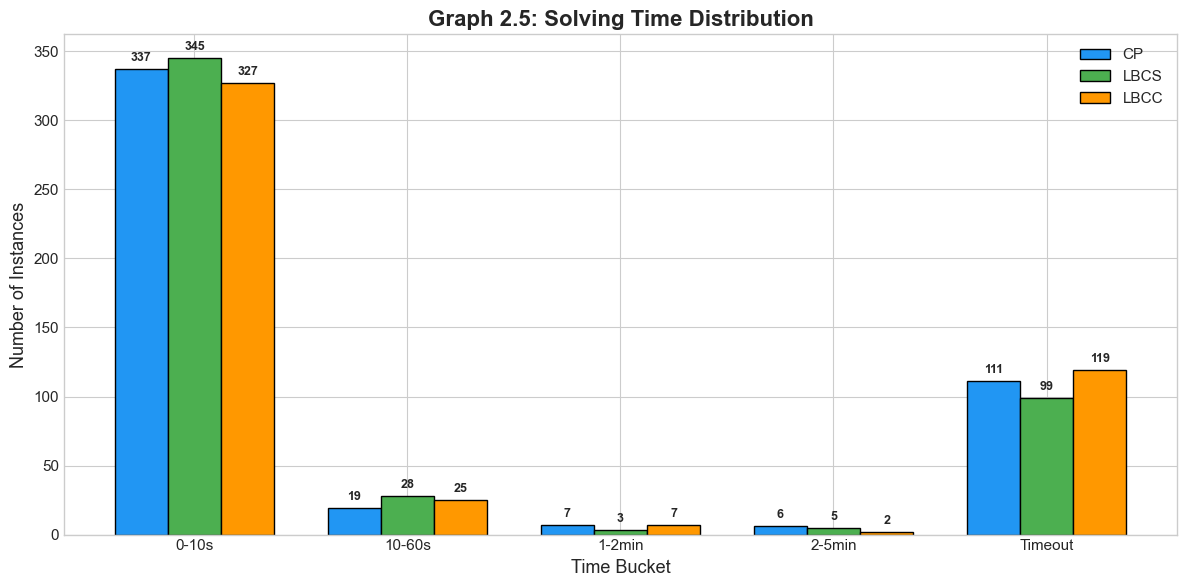

In [13]:
def categorize_time(row):
    if not row['finished']:
        return 'Timeout'
    t = row['time']
    if t <= 10:  return '0-10s'
    if t <= 60:  return '10-60s'
    if t <= 120: return '1-2min'
    return '2-5min'

bin_labels = ['0-10s', '10-60s', '1-2min', '2-5min', 'Timeout']
bin_counts = {}
for h, label in zip(heuristics, h_labels):
    df = dfs[h].copy()
    df['time_bin'] = df.apply(categorize_time, axis=1)
    counts = df['time_bin'].value_counts()
    bin_counts[label] = [counts.get(b, 0) for b in bin_labels]

x = np.arange(len(bin_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, (label, h) in enumerate(zip(h_labels, heuristics)):
    bars = ax.bar(x + i * width, bin_counts[label], width,
                  label=label, color=COLORS[h], edgecolor='black')
    add_bar_labels(ax, bars, fontsize=9)

ax.set_xlabel('Time Bucket')
ax.set_ylabel('Number of Instances')
ax.set_title('Graph 2.5: Solving Time Distribution')
ax.set_xticks(x + width)
ax.set_xticklabels(bin_labels)
ax.legend()
plt.tight_layout()
savefig(fig, 'graph_2_5_time_distribution')
plt.show()

### 2.6 Node Comparison Winners (Pairwise vs CP)

For instances solved by all three, how often does each heuristic expand fewer nodes than CP?

**Key takeaway**: LBCS uses fewer nodes than CP in ~44.5% of cases;
LBCC uses fewer in ~63.1% of cases, showing LBCC's stronger pruning.

Saved: figures/graph_2_6_node_winners.png


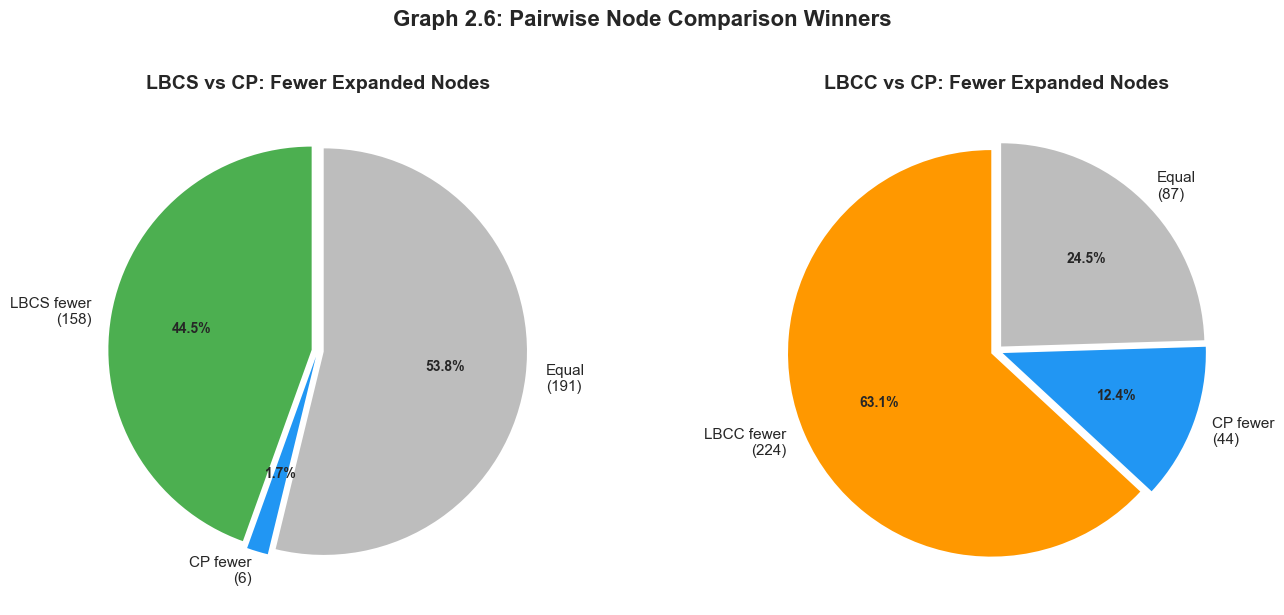

LBCS vs CP: LBCS fewer=158 (44.5%), CP fewer=6 (1.7%), Equal=191
LBCC vs CP: LBCC fewer=224 (63.1%), CP fewer=44 (12.4%), Equal=87


In [14]:
n_total = len(all_three_solved)

# LBCS vs CP
lbcs_wins = (all_three_solved['expand_number_lbcs'] < all_three_solved['expand_number_cp']).sum()
cp_wins_vs_lbcs = (all_three_solved['expand_number_cp'] < all_three_solved['expand_number_lbcs']).sum()
ties_lbcs = n_total - lbcs_wins - cp_wins_vs_lbcs

# LBCC vs CP
lbcc_wins = (all_three_solved['expand_number_lbcc'] < all_three_solved['expand_number_cp']).sum()
cp_wins_vs_lbcc = (all_three_solved['expand_number_cp'] < all_three_solved['expand_number_lbcc']).sum()
ties_lbcc = n_total - lbcc_wins - cp_wins_vs_lbcc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# LBCS vs CP
sizes1 = [lbcs_wins, cp_wins_vs_lbcs, ties_lbcs]
labels1 = [f'LBCS fewer\n({lbcs_wins})', f'CP fewer\n({cp_wins_vs_lbcs})', f'Equal\n({ties_lbcs})']
colors1 = [COLORS['LBCS'], COLORS['CP_DP'], '#BDBDBD']
wedges1, texts1, autotexts1 = ax1.pie(
    sizes1, labels=labels1, colors=colors1, autopct='%1.1f%%',
    startangle=90, explode=(0.03, 0.03, 0.03),
    textprops={'fontsize': 11})
for at in autotexts1:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax1.set_title('LBCS vs CP: Fewer Expanded Nodes', fontsize=14, fontweight='bold')

# LBCC vs CP
sizes2 = [lbcc_wins, cp_wins_vs_lbcc, ties_lbcc]
labels2 = [f'LBCC fewer\n({lbcc_wins})', f'CP fewer\n({cp_wins_vs_lbcc})', f'Equal\n({ties_lbcc})']
colors2 = [COLORS['LBCC'], COLORS['CP_DP'], '#BDBDBD']
wedges2, texts2, autotexts2 = ax2.pie(
    sizes2, labels=labels2, colors=colors2, autopct='%1.1f%%',
    startangle=90, explode=(0.03, 0.03, 0.03),
    textprops={'fontsize': 11})
for at in autotexts2:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax2.set_title('LBCC vs CP: Fewer Expanded Nodes', fontsize=14, fontweight='bold')

plt.suptitle('Graph 2.6: Pairwise Node Comparison Winners',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
savefig(fig, 'graph_2_6_node_winners')
plt.show()

print(f'LBCS vs CP: LBCS fewer={lbcs_wins} ({lbcs_wins/n_total*100:.1f}%), '
      f'CP fewer={cp_wins_vs_lbcs} ({cp_wins_vs_lbcs/n_total*100:.1f}%), '
      f'Equal={ties_lbcs}')
print(f'LBCC vs CP: LBCC fewer={lbcc_wins} ({lbcc_wins/n_total*100:.1f}%), '
      f'CP fewer={cp_wins_vs_lbcc} ({cp_wins_vs_lbcc/n_total*100:.1f}%), '
      f'Equal={ties_lbcc}')

### 2.7 Uniquely Solved Instances

Instances solved by exactly one heuristic but not the other two.

**Key takeaway**: LBCS uniquely solves 12 instances (mostly at RS=0.2),
CP uniquely solves 2, and LBCC uniquely solves 0.
This highlights LBCS's unique strength on resource-scarce problems.

=== Uniquely Solved Instances ===

CP: 2 uniquely solved
  RS=0.5: 2 instances

LBCS: 12 uniquely solved
  RS=0.2: 7 instances
  RS=0.5: 4 instances
  RS=0.7: 1 instances

LBCC: 0 uniquely solved
Saved: figures/graph_2_7_uniquely_solved.png


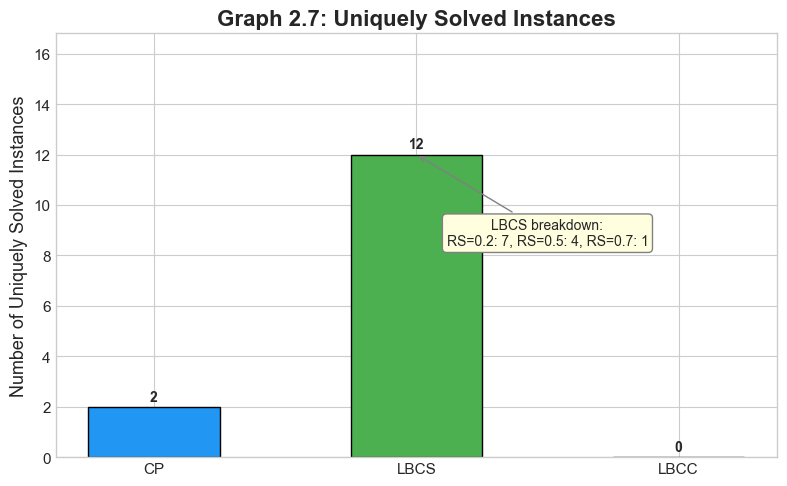

In [15]:
fin_cols = {'CP_DP': 'finished_cp', 'LBCS': 'finished_lbcs', 'LBCC': 'finished_lbcc'}

unique_solved = {}
for h in heuristics:
    my_col = fin_cols[h]
    other_cols = [c for k, c in fin_cols.items() if k != h]
    mask = (merged[my_col] == True) & (merged[other_cols[0]] == False) & (merged[other_cols[1]] == False)
    unique_solved[h] = merged[mask]

print('=== Uniquely Solved Instances ===')
for h, label in zip(heuristics, h_labels):
    df_u = unique_solved[h]
    print(f'\n{label}: {len(df_u)} uniquely solved')
    if len(df_u) > 0:
        rs_dist = df_u['RS'].value_counts().sort_index()
        for rs_val, count in rs_dist.items():
            print(f'  RS={rs_val}: {count} instances')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
unique_counts = [len(unique_solved[h]) for h in heuristics]
bars = ax.bar(h_labels, unique_counts, color=h_colors, edgecolor='black', width=0.5)
add_bar_labels(ax, bars)
ax.set_ylabel('Number of Uniquely Solved Instances')
ax.set_title('Graph 2.7: Uniquely Solved Instances')
ax.set_ylim(0, max(unique_counts) * 1.4 if max(unique_counts) > 0 else 5)

# Add RS breakdown annotation for LBCS
if len(unique_solved['LBCS']) > 0:
    rs_breakdown = unique_solved['LBCS']['RS'].value_counts().sort_index()
    text_parts = [f'RS={rs}: {cnt}' for rs, cnt in rs_breakdown.items()]
    ax.annotate('LBCS breakdown:\n' + ', '.join(text_parts),
                xy=(1, unique_counts[1]), xytext=(1.5, unique_counts[1] * 0.7),
                fontsize=10, ha='center',
                arrowprops=dict(arrowstyle='->', color='gray'),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.tight_layout()
savefig(fig, 'graph_2_7_uniquely_solved')
plt.show()

---
# Section 3: Comparison with Previous Project

The previous project (Ido's work) used TPPN+CPM and solved 354 out of 480 instances.
This section shows how each of our configurations compares to that baseline.

### 3.1 Solve Rates \u2014 All Configurations (Sorted)

Horizontal bar chart showing all configurations sorted by solve count.

**Key takeaway**: All new configurations exceed the previous baseline of 354.
LBCS achieves the highest solve rate at 381 (79.4%), a +7.6% improvement.

Saved: figures/graph_3_1_all_configurations.png


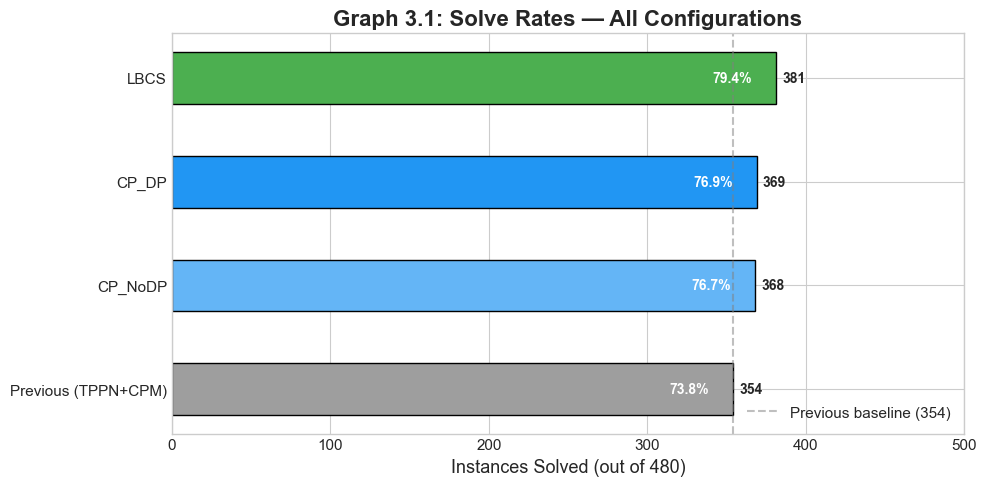


Improvement over previous (354):
  CP_NoDP: 368 solved (+14, +4.0%)
  CP_DP: 369 solved (+15, +4.2%)
  LBCS: 381 solved (+27, +7.6%)


In [16]:
results = {
    'Previous (TPPN+CPM)': 354,
    'CP_NoDP': int(dfs['CP_NoDP']['finished'].sum()),
    'CP_DP': int(dfs['CP_DP']['finished'].sum()),
    'LBCS': int(dfs['LBCS']['finished'].sum()),
}
sorted_results = dict(sorted(results.items(), key=lambda x: x[1]))

color_map = {
    'Previous (TPPN+CPM)': COLORS['previous'],
    'CP_NoDP': COLORS['CP_NoDP'],
    'CP_DP': COLORS['CP_DP'],
    'LBCS': COLORS['LBCS'],
}
bar_colors = [color_map[k] for k in sorted_results.keys()]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(list(sorted_results.keys()), list(sorted_results.values()),
               color=bar_colors, edgecolor='black', height=0.5)
add_bar_labels_h(ax, bars)
ax.set_xlabel('Instances Solved (out of 480)')
ax.set_title('Graph 3.1: Solve Rates \u2014 All Configurations')
ax.set_xlim(0, 500)
ax.axvline(x=354, color='gray', linestyle='--', alpha=0.5,
           label='Previous baseline (354)')
ax.legend(loc='lower right')

# Add percentage labels
for bar, (name, count) in zip(bars, sorted_results.items()):
    pct = count / 480 * 100
    ax.text(count - 15, bar.get_y() + bar.get_height() / 2.,
            f'{pct:.1f}%', ha='right', va='center',
            fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
savefig(fig, 'graph_3_1_all_configurations')
plt.show()

print('\nImprovement over previous (354):')
for name, count in sorted_results.items():
    if name != 'Previous (TPPN+CPM)':
        improvement = (count - 354) / 354 * 100
        print(f'  {name}: {count} solved (+{count-354}, +{improvement:.1f}%)')

---
# Summary

| Metric | CP_DP | CP_NoDP | LBCS | LBCC |
|--------|-------|---------|------|------|
| Solved (out of 480) | 369 | 368 | **381** | 361 |
| Solve Rate | 76.9% | 76.7% | **79.4%** | 75.2% |
| Avg Expanded (all-3-solved) | ~251K | \u2014 | ~227K | **~165K** |
| vs Previous (+354) | +15 | +14 | **+27** | +7 |

**Key findings**:
1. **DP vs NoDP**: DP provides a ~1.32x speed improvement with nearly identical solve rates.
   In mutual timeouts, DP explores ~24% more nodes (98% of the time), proving faster per-node throughput.
2. **LBCS is the best overall heuristic** with 381/480 solved, 27 more than the previous project.
3. **LBCC is the most node-efficient** heuristic, expanding ~34% fewer nodes than CP on average,
   but its computation overhead results in a lower overall solve rate (361).
4. All new heuristics outperform the previous project baseline of 354.